In [23]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim


In [24]:
# Create a manual seed to reproduce your results
torch.manual_seed(42)

In [25]:
df = pd.read_csv("fmnist_small.csv")

In [26]:
df.head() # This is an image dataset apparently on fashion products and all

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [27]:
# So here each pixel value of the grid was squeezed into a single row by placing the original grid rows side by side
# The label values are some sort of identity of these products.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 35.9 MB


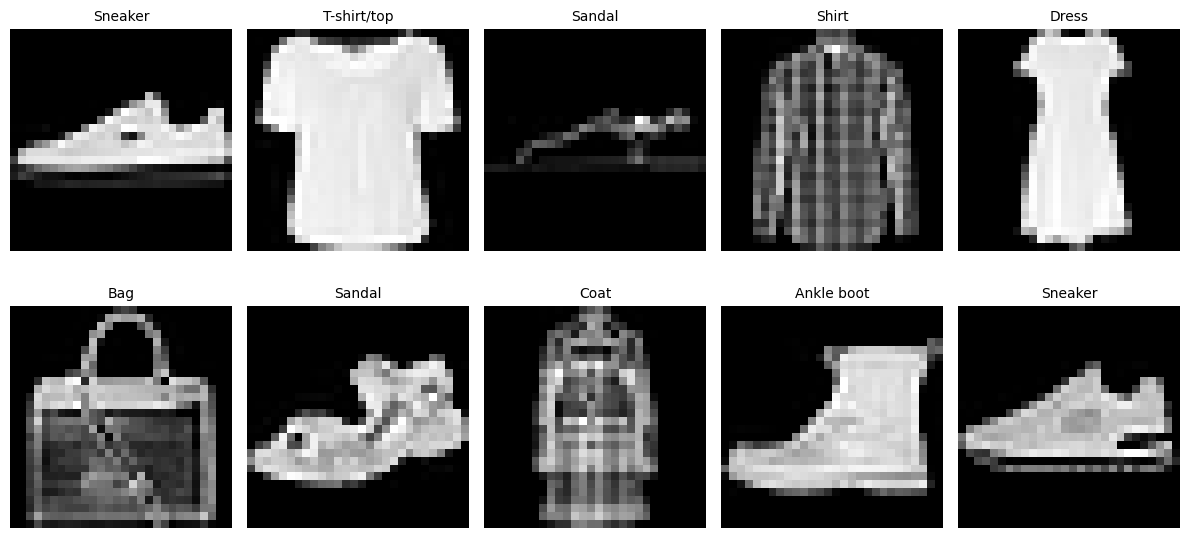

In [29]:
# Plotting the rows one by one

# 1. Define the descriptive text labels for Fashion MNIST
label_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# 2. Sample 10 random rows from your loaded DataFrame
sample_df = df.sample(n=10, random_state=42)

# 3. Setup a grid layout (2 rows by 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, (index, row) in enumerate(sample_df.iterrows()):
    # Get the clothing category index from the 'label' column
    label_idx = int(row["label"])

    # Drop the label to keep only the pixel values (pixel1 to pixel784)
    pixel_values = row.drop("label").values

    # Reshape the flat 784 pixels back into a 28x28 grid
    image_matrix = pixel_values.reshape(28, 28)

    # Plot the matrix using a grayscale map
    axes[i].imshow(image_matrix, cmap="gray")
    axes[i].set_title(label_names[label_idx], fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [30]:
# Split the dataset inton X and y , and then training and testing split.
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
# Now StandardScale the features
X_train = X_train/255.0
X_test = X_test/255.0

In [32]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [33]:
# Create a Dataset Class
class MyCustomDataset(Dataset):
  def __init__(self,features,labels):
     super().__init__()
     self.features = torch.tensor(features,dtype=torch.float32)
     self.labels = torch.tensor(labels,dtype=torch.long)
  def __len__(self):
    return self.features.shape[0]
  def __getitem__(self,index):
    return self.features[index],self.labels[index]

# Instantiate training and testing objects to pass on to DataLoader
training_dataset = MyCustomDataset(X_train,y_train)
testing_dataset = MyCustomDataset(X_test,y_test)

# Create training and testing loaders
train_loader = DataLoader(training_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(testing_dataset,batch_size=32,shuffle=True)

In [34]:
# Create the Neural Network
class FMNN(nn.Module):
  def __init__(self,n_features):
     super().__init__()
     self.network = nn.Sequential(
         nn.Linear(n_features,128),
         nn.ReLU(),
         nn.Linear(128,64),
         nn.ReLU(),
         nn.Linear(64,10)
     )
  def forward(self,x):
    return self.network(x)

In [35]:
# Set Parameters
learning_rate = 0.1
epochs = 100

In [36]:
# Instantiate the model
model = FMNN(X_train.shape[1])

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [37]:
# Model Training

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_X,batch_y in train_loader:

    # Forward pass the first batch of X and get the outputs
    y_pred = model(batch_X)

    # Calculate the loss value
    loss = criterion(y_pred, batch_y) # This captures the loss itself and we do not need sigmoid here as the values are to be expected in float

    # Backward Pass the loss
    optimizer.zero_grad() # Clear gradients to avoid passsing loss of previous batch
    loss.backward()

    # Update the parameters
    optimizer.step()

    # Epoch loss for this batch (Keeps on adding all batch loss across epoch)
    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  if (epoch+1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 10 , Loss: 0.3984092291692893
Epoch: 20 , Loss: 0.26237100958824155
Epoch: 30 , Loss: 0.18886244976272185
Epoch: 40 , Loss: 0.13288619516184552
Epoch: 50 , Loss: 0.10084663986538847
Epoch: 60 , Loss: 0.0789726735604927
Epoch: 70 , Loss: 0.05125938480564703
Epoch: 80 , Loss: 0.023853825814827968
Epoch: 90 , Loss: 0.06782017603516578
Epoch: 100 , Loss: 0.008310633393703028


In [38]:
model.eval()  # Evaluate the model

FMNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [39]:
# Make predictions on testing batch .

total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.8325


In [40]:
# This is a basic implementation of how we do a complete worflow and not how we would ideally work on this dataset.
# We should have made a Convolutional Neural Network for this but this was just a pure demonstration on practicing how the complete pipeline looks in pytorch